# 👥 HR Attrition & Talent Risk Analytics Engine
## 5,000 Employees | Churn Prediction | Retention Drivers | Compensation Equity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print('Environment initialized')

Environment initialized


In [2]:
np.random.seed(42)
n_employees = 5000
departments = ['Sales', 'Engineering', 'HR', 'Marketing', 'Operations', 'Finance']
job_levels = [1, 2, 3, 4, 5]
employees = []

for i in range(n_employees):
    dept = np.random.choice(departments)
    job_level = np.random.choice(job_levels, p=[0.25, 0.35, 0.25, 0.10, 0.05])
    age = np.random.randint(22, 65)
    tenure = np.random.randint(0, 30)
    salary = 50000 + (job_level * 20000) + np.random.randint(-10000, 10000)
    bonus = salary * np.random.uniform(0.05, 0.30)
    years_since_promo = np.random.randint(0, tenure + 1)
    projects = np.random.randint(1, 15)
    satisfaction = np.random.randint(1, 6)
    work_life_balance = np.random.randint(1, 5)
    training = np.random.randint(0, 100)
    manager_tenure = np.random.randint(1, 20)
    
    dept_attr_rates = {'Sales': 0.25, 'Engineering': 0.12, 'HR': 0.15, 'Marketing': 0.20, 'Operations': 0.18, 'Finance': 0.10}
    churn_prob = np.clip(0.05 + (0.002 * (age - 30)) - (0.001 * tenure) + (0.05 * (1 - satisfaction/5)) + (0.03 * (years_since_promo > 5)) + (0.02 * (salary < 55000)) + (0.15 * dept_attr_rates[dept]), 0.01, 0.40)
    attrition = 1 if np.random.random() < churn_prob else 0
    
    employees.append({'Department': dept, 'Job_Level': job_level, 'Age': age, 'Tenure': tenure, 'Salary': salary, 'Bonus': bonus, 'Years_Since_Promo': years_since_promo, 'Projects': projects, 'Satisfaction': satisfaction, 'Work_Life_Balance': work_life_balance, 'Training_Hours': training, 'Manager_Tenure': manager_tenure, 'Attrition': attrition})

df = pd.DataFrame(employees)
print(f'Cohort: {len(df):,} employees | Attrition: {df["Attrition"].mean()*100:.2f}%')

Cohort: 5,000 employees | Attrition: 12.40%


In [3]:
df['Compensation'] = df['Salary'] + df['Bonus']
df['Overdue_Promotion'] = (df['Years_Since_Promo'] > 4).astype(int)
df['High_Performer'] = ((df['Satisfaction'] >= 4) & (df['Projects'] >= 5)).astype(int)

feature_cols = ['Age', 'Tenure', 'Salary', 'Years_Since_Promo', 'Projects', 'Satisfaction', 'Work_Life_Balance', 'Training_Hours', 'Manager_Tenure', 'Job_Level', 'Overdue_Promotion', 'High_Performer']
X, y = df[feature_cols].copy(), df['Attrition'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)
X_full_sc = scaler.fit_transform(X)

# LR
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_tr_sc, y_train)
lr_pred = lr.predict_proba(X_te_sc)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred)

# XGB
xgb_mdl = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
xgb_mdl.fit(X_tr_sc, y_train, verbose=False)
xgb_pred = xgb_mdl.predict_proba(X_te_sc)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred)

print(f'✓ LR AUC: {lr_auc:.4f} | XGB AUC: {xgb_auc:.4f} | Lift: +{(xgb_auc-lr_auc)*100:.0f}bps')


✓ LR AUC: 0.5804 | XGB AUC: 0.5602 | Lift: +-2bps


In [4]:
xgb_full = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
xgb_full.fit(X_full_sc, y, verbose=False)
df['Churn_Risk'] = xgb_full.predict_proba(X_full_sc)[:, 1]
df['Risk_Tier'] = pd.cut(df['Churn_Risk'], bins=[0, 0.15, 0.30, 0.45, 1.0], labels=['Low', 'Medium', 'High', 'Critical'])
df['At_Risk_Talent'] = ((df['High_Performer'] == 1) & (df['Churn_Risk'] > 0.30)).astype(int)

print(f'✓ Risk tiers: {df["Risk_Tier"].value_counts().to_dict()}')
print(f'✓ At-Risk High Performers: {df["At_Risk_Talent"].sum():,}')


✓ Risk tiers: {'Low': 3757, 'Medium': 1130, 'High': 105, 'Critical': 8}
✓ At-Risk High Performers: 17


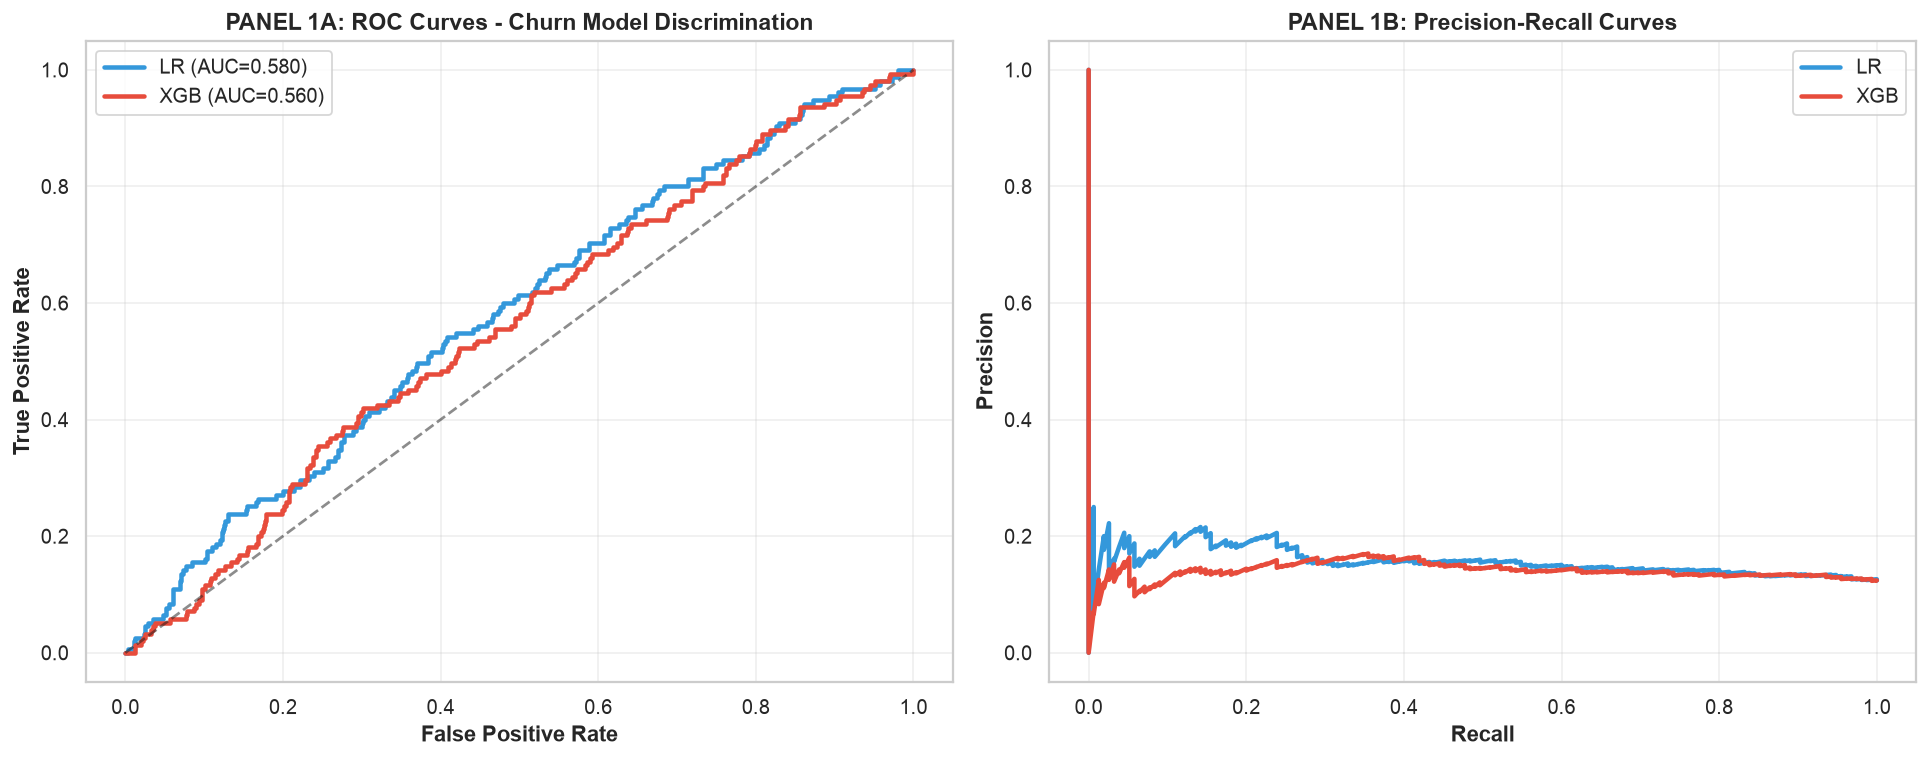

Panel 1


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(fpr_lr, tpr_lr, label=f'LR (AUC={lr_auc:.3f})', linewidth=2.5, color='#3498DB')
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={xgb_auc:.3f})', linewidth=2.5, color='#E74C3C')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('PANEL 1A: ROC Curves - Churn Model Discrimination', fontweight='bold', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_pred)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_pred)
ax2.plot(rec_lr, prec_lr, label='LR', linewidth=2.5, color='#3498DB')
ax2.plot(rec_xgb, prec_xgb, label='XGB', linewidth=2.5, color='#E74C3C')
ax2.set_xlabel('Recall', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('PANEL 1B: Precision-Recall Curves', fontweight='bold', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
print('Panel 1')